# Bi-FORK Beam3D Demo

The dataset describes a 3D beam-buckling process, containing simulations with 3 to 11 nodes. In the problem setting, the beam is fixed at the base and aligned along the $z$-axis in its undeformed state, with a specified downward displacement applied incrementally to the tip.
At a critical displacement it buckles, and because the beam is rotationally symmetric it can buckle in **any** horizontal direction. Bi-FORK learns to generate these buckling trajectories such that the generated directions cover the full circle.

This notebook:
1. generates the data,
2. trains the two stages (the autoencoder is optional),
3. loads the second-stage model and samples buckling trajectories for one beam, with Bi-FORK w/o particle guidance and Bi-FORK, and compares the two.

## Initialization

In [2]:
import os
import sys
from argparse import Namespace
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO = Path.cwd()
os.chdir(REPO)
sys.path.append(str(REPO / "scripts"))

from scripts.particle_guidance import bifurcation_frames, build
from bifurcation.callbacks.generation import sample_row
from bifurcation.models.transport.azula import PGFlexGaussianDenoiser
from bifurcation.viz.beam3d import draw_mode

torch.set_float32_matmul_precision("high")
PYTHON = sys.executable

## Configuration

All settings live in this cell. Each training stage can be switched off, e.g. to only sample from an existing checkpoint.

In [3]:
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
SEED = 42

# --- paths ---
DATA_DIR = REPO / "data"
MODELS_ROOT = REPO / ".models"  # checkpoints and CSV logs
LOGS_ROOT = REPO / ".logs"      # Hydra configs and training logs
LOGGER = "csv"                  # or "wandb_and_csv" to also log to W&B

# --- first stage: autoencoder (optional) ---
TRAIN_FIRST_STAGE = False
FIRST_STAGE_CKPT = MODELS_ROOT / "beam3d" / "first_stage" / f"seed_{SEED}" / "checkpoints" / "final.ckpt"

# --- second stage: latent flow matching ---
# model and optimizer settings come from configs/model/beam3d/second_stage.yaml.
TRAIN_SECOND_STAGE = False
MAX_STEPS = 10
VAL_CHECK_INTERVAL = 2

SECOND_STAGE_DIR = MODELS_ROOT / "beam3d" / "second_stage" / f"seed_{SEED}"
SECOND_STAGE_CKPT = SECOND_STAGE_DIR / "checkpoints" / "final.ckpt"
SECOND_STAGE_CONFIG = LOGS_ROOT / "beam3d" / "second_stage" / f"seed_{SEED}" / "train" / ".hydra" / "config.yaml"

# --- sampling ---
SPLIT = "test"
SAMPLE_INDEX = 41   # desired index for sample figure
N_TRIALS = 180      # generated trajectories per beam
DDIM_STEPS = 10

# --- particle guidance ---
W_SCORE_HAT = 1.0          # weight of the model's own score
W_SCORE_REPULSIVE = 1.0    # strength of the repulsion between trials
SCHEDULE_POWER = 1.0       # how the repulsion weight decays over sampling time
SCHEDULE_MIN_WEIGHT = 0.0  # lower bound on that weight

## Data

Generate 1000 random beams (2 to 10 elements with random lengths and stiffnesses), rotate each one to a random buckling direction, and split them into train/validation/test sets in `data/beam3d`. Skipped if the split already exists.

In [4]:
if not (DATA_DIR / "beam3d" / "train" / "BucklingBeams3D_data.pkl").exists():
    !{PYTHON} data_generation/beam3D/generate_dataset.py --n-samples 1000 --workers 16 --out {DATA_DIR}/BucklingBeams3D_data.pkl
    !{PYTHON} data_generation/create_data_split.py beam3d --input {DATA_DIR}/BucklingBeams3D_data.pkl --output {DATA_DIR}/beam3d 
else:
    print("Data found in", DATA_DIR / "beam3d")

Data found in data/beam3d


# Training

Both stages run through the Hydra entry point `python -m bifurcation.train`. The defaults are in `configs/experiment/beam3d/` and `configs/model/beam3d/`. All settings from above are passed as overrides to the config file.

### First stage: autoencoder (optional)

The autoencoder compresses every frame of a beam rollout into a small set of latent tokens and decodes them back to node positions. Skip it if you already have a checkpoint at `FIRST_STAGE_CKPT`.

In [5]:
if TRAIN_FIRST_STAGE:
    !{PYTHON} -m bifurcation.train experiment=beam3d/first_stage paths.models_root={MODELS_ROOT} paths.logs_root={LOGS_ROOT} logger={LOGGER} seed={SEED}
    FIRST_STAGE_CKPT = MODELS_ROOT / "beam3d" / "first_stage" / f"seed_{SEED}" / "checkpoints" / "final.ckpt"

assert FIRST_STAGE_CKPT.exists(), f"First-stage checkpoint not found: {FIRST_STAGE_CKPT}"

### Second stage: latent flow matching

Training runs for `MAX_STEPS` steps. Every `VAL_CHECK_INTERVAL` steps the validation loss is computed and the model generates trajectories for validation beams. Their buckling directions and a gallery of them are plotted to `<run>/csv/plots`.

For a quick test, set `MAX_STEPS` to a few hundred and `VAL_CHECK_INTERVAL` below it.

In [6]:
if TRAIN_SECOND_STAGE:
    overrides = " ".join([
        "experiment=beam3d/second_stage",
        f"model.first_stage_ckpt={FIRST_STAGE_CKPT}",
        f"paths.models_root={MODELS_ROOT}",
        f"paths.logs_root={LOGS_ROOT}",
        f"logger={LOGGER}",
        f"seed={SEED}",
        f"trainer.max_steps={MAX_STEPS}",
        f"trainer.val_check_interval={VAL_CHECK_INTERVAL}",
    ])
    !{PYTHON} -m bifurcation.train {overrides}

print("Second-stage checkpoint:", SECOND_STAGE_CKPT)

Second-stage checkpoint: .models/beam3d/second_stage/seed_42/checkpoints/final.ckpt


Loss curves from the CSV log. `train/loss` is logged every 50 steps, `val/loss` every `VAL_CHECK_INTERVAL` steps.

In [7]:
metrics_csv = SECOND_STAGE_DIR / "csv" / "metrics.csv"
if TRAIN_SECOND_STAGE and metrics_csv.exists():
    metrics = pd.read_csv(metrics_csv)

    fig, ax = plt.subplots(figsize=(6, 4))
    for column in ["train/loss", "val/loss"]:
        if column in metrics:
            values = metrics.dropna(subset=[column])
            ax.plot(values["step"], values[column], marker=".", label=column)
    ax.set_xlabel("step")
    ax.set_yscale("log")
    ax.set_title("Flow-matching loss")
    ax.legend()
    plt.show()
else:
    print("No second-stage training in this run; skipping loss curves.")

No second-stage training in this run; skipping loss curves.


## Load model

build (from `scripts/particle_guidance.py`) loads the second-stage checkpoint with the model config it was trained with. The checkpoint already contains the frozen autoencoder. It also returns the data split and the `Generate` helper that the training callbacks use to sample and score trajectories.

In [8]:
# A run trained above uses its saved Hydra config; otherwise configs/model/beam3d/second_stage.yaml
MODEL_CONFIG = SECOND_STAGE_CONFIG if TRAIN_SECOND_STAGE and SECOND_STAGE_CONFIG.exists() else None
args = Namespace(
    dataset="beam3d",
    ckpt=SECOND_STAGE_CKPT,
    model_config=MODEL_CONFIG,
    env="local",
    data_dir=DATA_DIR,
    split=SPLIT,
    device=DEVICE,
    n_samples=None,
    n_trials=N_TRIALS,
    num_steps=DDIM_STEPS,
)
model, view, generator = build(args)
generator.keep_outputs = True 
print(f"{len(view.dataset)} beams in the {SPLIT} split")

150 beams in the test split


## The demo beam

The ground truth is stored with the beam buckling towards $+x$. Any rotation of it about the vertical axis is an equally valid solution.

9 elements, total length 8.68, 200 displacement steps, buckles at step 8


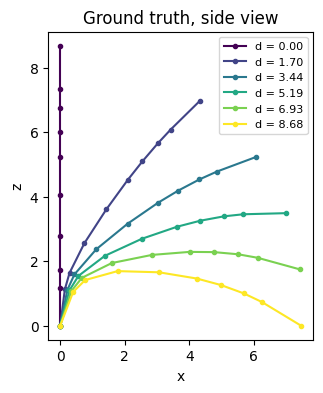

In [9]:
sample = view.dataset[SAMPLE_INDEX]
X_gt = sample.X(0)  # [T, N+1, 3] deformed node positions
print(f"{sample.n_elements} elements, total length {sample.total_length:.2f}, "
      f"{X_gt.shape[0]} displacement steps, buckles at step {sample.buckling_start_frame}")

frames = np.linspace(0, X_gt.shape[0] - 1, 6).astype(int)
colors = plt.cm.viridis(np.linspace(0, 1, len(frames)))
fig, ax = plt.subplots(figsize=(4, 4))
for t, c in zip(frames, colors):
    ax.plot(X_gt[t, :, 0], X_gt[t, :, 2], "o-", ms=3, color=c, label=f"d = {sample.U[t, 0]:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_aspect("equal")
ax.set_title("Ground truth, side view")
ax.legend(fontsize=8)
plt.show()

## Bi-FORK without particle guidance

Draw `N_TRIALS` trajectories for the demo beam. Every trial starts from independent noise; nothing pushes the trials apart.

In [10]:
torch.manual_seed(SEED)
model.azula_denoiser_factory = None
with torch.inference_mode():
    plain = generator.generate_for(model, view, [SAMPLE_INDEX], desc="plain")[0]

[gen:plain] sample 1/1 (cov 0.92 jsd 0.05 rej 0.00 mcon_mse 0.0012 adv +18.3769) [sample 83%/2.6s frames 6%/0.2s decode 6%/0.2s score 2%/0.1s label 1%/0.0s gen 1%/0.0s denorm 0%/0.0s report 0%/0.0s data 0%/0.0s]


## Bi-FORK

With [particle guidance](https://arxiv.org/abs/2310.13102), the `N_TRIALS` trajectories are sampled **jointly**. At every sampler step, each trial's score gets an extra term that pushes it away from the other trials (an RBF kernel on their predicted clean latents):

$$\text{score} = w_{\text{hat}} \cdot \text{score}_\text{model} + w_{\text{rep}} \cdot \text{score}_\text{repulsive}$$

The repulsion only acts on the frames where the model's bifurcation head predicts that the beam has buckled. Before that, all trials should agree on the straight, compressed beam. The result is a set of trajectories that spreads more evenly over the buckling directions.

In [12]:
with torch.inference_mode():
    frames = bifurcation_frames(model, view, SAMPLE_INDEX, DEVICE)
print(f"repulsion active on {int(frames.sum())} of {len(frames)} frames")

torch.manual_seed(SEED)
model.azula_denoiser_factory = partial(
    PGFlexGaussianDenoiser,
    w_score_hat=W_SCORE_HAT,
    w_score_repulsive=W_SCORE_REPULSIVE,
    bifurcation_frames=frames,
    schedule_power=SCHEDULE_POWER,
    schedule_min_weight=SCHEDULE_MIN_WEIGHT,
)
with torch.inference_mode():
    guided = generator.generate_for(model, view, [SAMPLE_INDEX], desc="particle_guidance")[0]
model.azula_denoiser_factory = None

repulsion active on 192 of 200 frames
[gen:particle_guidance] sample 1/1 (cov 0.96 jsd 0.05 rej 0.00 mcon_mse 0.0012 adv +18.3769) [sample 85%/2.9s frames 6%/0.2s decode 5%/0.2s score 2%/0.1s label 1%/0.0s gen 1%/0.0s denorm 0%/0.0s report 0%/0.0s data 0%/0.0s]


## Comparison

- **coverage**: share of the direction bins that at least one trial lands in (higher is better).
- **mode_jsd**: Jensen-Shannon divergence between the distribution of buckling directions and a uniform one (lower is better).
- **mcon_mae**: error between each trial and the ground-truth trajectory rotated to the trial's direction (lower is better).

In [13]:
results = {"Bi-FORK w/o PG": plain, "Bi-FORK": guided}
rows = {name: sample_row(r, generator.min_fraction) for name, r in results.items()}
pd.DataFrame(rows).loc[["coverage", "mode_jsd", "rejected", "mcon_mae"]]

,Bi-FORK w/o PG,Bi-FORK
coverage,0.92,0.96
mode_jsd,0.05091,0.047438
rejected,0.0,0.0
mcon_mae,0.013452,0.013788


We plot the actual vs predicted trajectory for the pre-defined index. Additionally we show the predicted distribution against the desired circle endpoint view.

Bi-FORK w/o PG: trial 63 shown, error 0.014 (all trials: min 0.009, max 0.016), 0 of 180 rejected
Bi-FORK: trial 57 shown, error 0.013 (all trials: min 0.009, max 0.017), 0 of 180 rejected


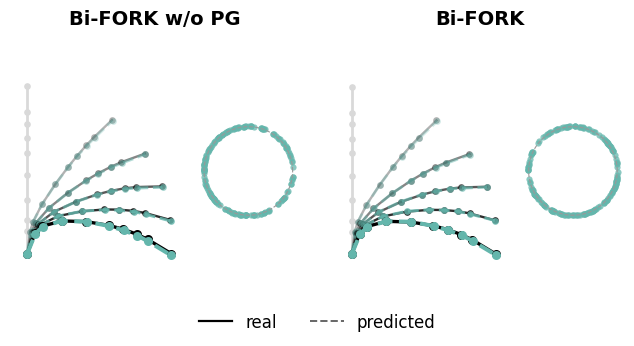

In [16]:
import logging

from bifurcation.viz.beam3d import aligned_errors, plot_mode_comparison, typical_trial

logging.getLogger("matplotlib.axes._base").setLevel(logging.ERROR)  # expected aspect/limit notices

for name, r in results.items():
    errors, shown = aligned_errors(r.sample, r.Y_gen), typical_trial(r.sample, r.Y_gen, r.rollout_labels)
    n_rejected = sum(label < 0 for label in r.rollout_labels)
    print(f"{name}: trial {shown} shown, error {errors[shown]:.3f} "
          f"(all trials: min {errors.min():.3f}, max {errors.max():.3f}), {n_rejected} of {len(errors)} rejected")

fig = plot_mode_comparison(results)
plt.show()

A few individual trajectories, top view: the final buckled beam (red) and the path its tip swept (grey).

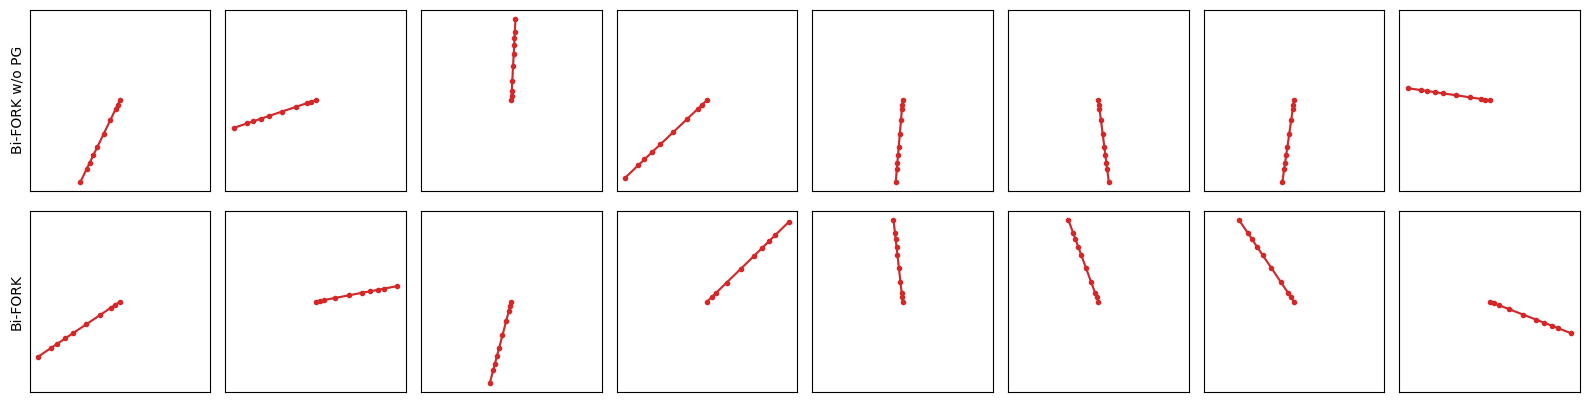

In [15]:
n_show = min(8, N_TRIALS)
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4.4))
for row, (name, r) in zip(axes, results.items()):
    for ax, Y in zip(row, r.Y_gen[:n_show]):
        draw_mode(ax, r.sample, Y)
    row[0].set_ylabel(name)
plt.tight_layout()
plt.show()

## Full evaluation (optional)

To score particle guidance on many test beams, run the evaluation script. It writes `samples.csv`, `report.csv` and `summary.txt` to `--out`.

In [15]:
RUN_FULL_EVAL = False

if RUN_FULL_EVAL:
    MODEL_CONFIG_ARG = f"--model-config {MODEL_CONFIG}" if MODEL_CONFIG is not None else ""
    !{PYTHON} scripts/particle_guidance.py --dataset beam3d --ckpt {SECOND_STAGE_CKPT} {MODEL_CONFIG_ARG} --data-dir {DATA_DIR} --n-samples 8 --n-trials 360 --num-steps {DDIM_STEPS} --w-score-repulsive {W_SCORE_REPULSIVE} --out particle_guidance_results/beam3d